# Hybrid Dataset Evaluation: EV Charger QR Recovery

This notebook evaluates a hybrid data strategy for EV charger QR recovery. It generates reproducible charger stickers with exact labels, simulates real scan failures, checks leakage-safe splits, and compares a raw OpenCV baseline with the service's preprocessing and decoder ensemble.

> Synthetic data supports controlled development, public degraded-QR data and held-out physical captures broaden evaluation, and verified domain scans provide production validation.

## 1. Generate a reproducible demonstration dataset

Every generated example has an exact `charger_id`, QR payload, sticker/session identity, degradation record, quality scores, decoder result, and pre-assigned group-safe split.

In [1]:
import importlib.util
import json
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    'MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'tap-electric-matplotlib')
)

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

REPOSITORY_NAME = 'tap-electric-qr-recovery'
REPOSITORY_URL = 'https://github.com/siddiqueMangi2003/tap-electric-qr-recovery.git'

candidates = [
    Path.cwd(),
    *Path.cwd().parents,
    Path('/kaggle/working') / REPOSITORY_NAME,
]
KAGGLE_INPUT = Path('/kaggle/input')
if KAGGLE_INPUT.exists():
    for module_path in KAGGLE_INPUT.rglob('synthetic_dataset.py'):
        if module_path.parent.name == 'ml' and module_path.parent.parent.name == 'app':
            candidates.append(module_path.parents[2])

PROJECT_ROOT = next(
    (path for path in candidates if (path / 'app' / 'ml' / 'synthetic_dataset.py').exists()),
    None,
)

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path('/kaggle/working') / REPOSITORY_NAME
    print(f'Repository not found; cloning it into {PROJECT_ROOT} ...')
    try:
        subprocess.run(
            ['git', 'clone', '--depth', '1', REPOSITORY_URL, str(PROJECT_ROOT)],
            check=True,
        )
    except subprocess.CalledProcessError as error:
        raise RuntimeError(
            'Could not download the repository. In Kaggle, enable Internet under '
            'Notebook options, or upload the repository as a Kaggle Dataset.'
        ) from error

missing_packages = []
if importlib.util.find_spec('qrcode') is None:
    missing_packages.append('qrcode[pil]>=8,<9')
if importlib.util.find_spec('zxingcpp') is None:
    missing_packages.append('zxing-cpp>=3.1,<4.0')
if missing_packages:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', *missing_packages],
        check=True,
    )

sys.path.insert(0, str(PROJECT_ROOT))
print(f'Using project checkout: {PROJECT_ROOT.name}')

from app.ml.synthetic_dataset import (  # noqa: E402
    SyntheticDatasetConfig,
    SyntheticDatasetGenerator,
)

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'notebook_demo'
config = SyntheticDatasetConfig(
    chargers=30,
    variants_per_charger=6,
    blur_variants_per_charger=2,
    seed=42,
)
manifest_path = SyntheticDatasetGenerator(config).generate(OUTPUT_DIR)
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
samples = pd.DataFrame(manifest['examples'])
print(f"Generated {len(samples)} images from {samples['charger_id'].nunique()} chargers")

Using project checkout: tap-electric-qr-recovery


Generated 180 images from 30 chargers


In [2]:
summary = pd.DataFrame({
    'examples': samples.groupby('split').size(),
    'unique_chargers': samples.groupby('split')['charger_id'].nunique(),
    'OpenCV baseline': samples.groupby('split')['native_qr_success'].mean(),
    'After recovery': samples.groupby('split')['recovered_qr_success'].mean(),
}).reindex(['train', 'validation', 'test'])
summary.style.format({'OpenCV baseline': '{:.1%}', 'After recovery': '{:.1%}'})

,examples,unique_chargers,OpenCV baseline,After recovery
split,,,,
train,126,21,66.7%,81.0%
validation,24,4,58.3%,66.7%
test,30,5,73.3%,83.3%


## 2. Inspect clean and degraded camera frames

The label stays constant while only the pixels change. The model sees the full camera frame; the deterministic decoder and OCR fallback operate on the same underlying image.

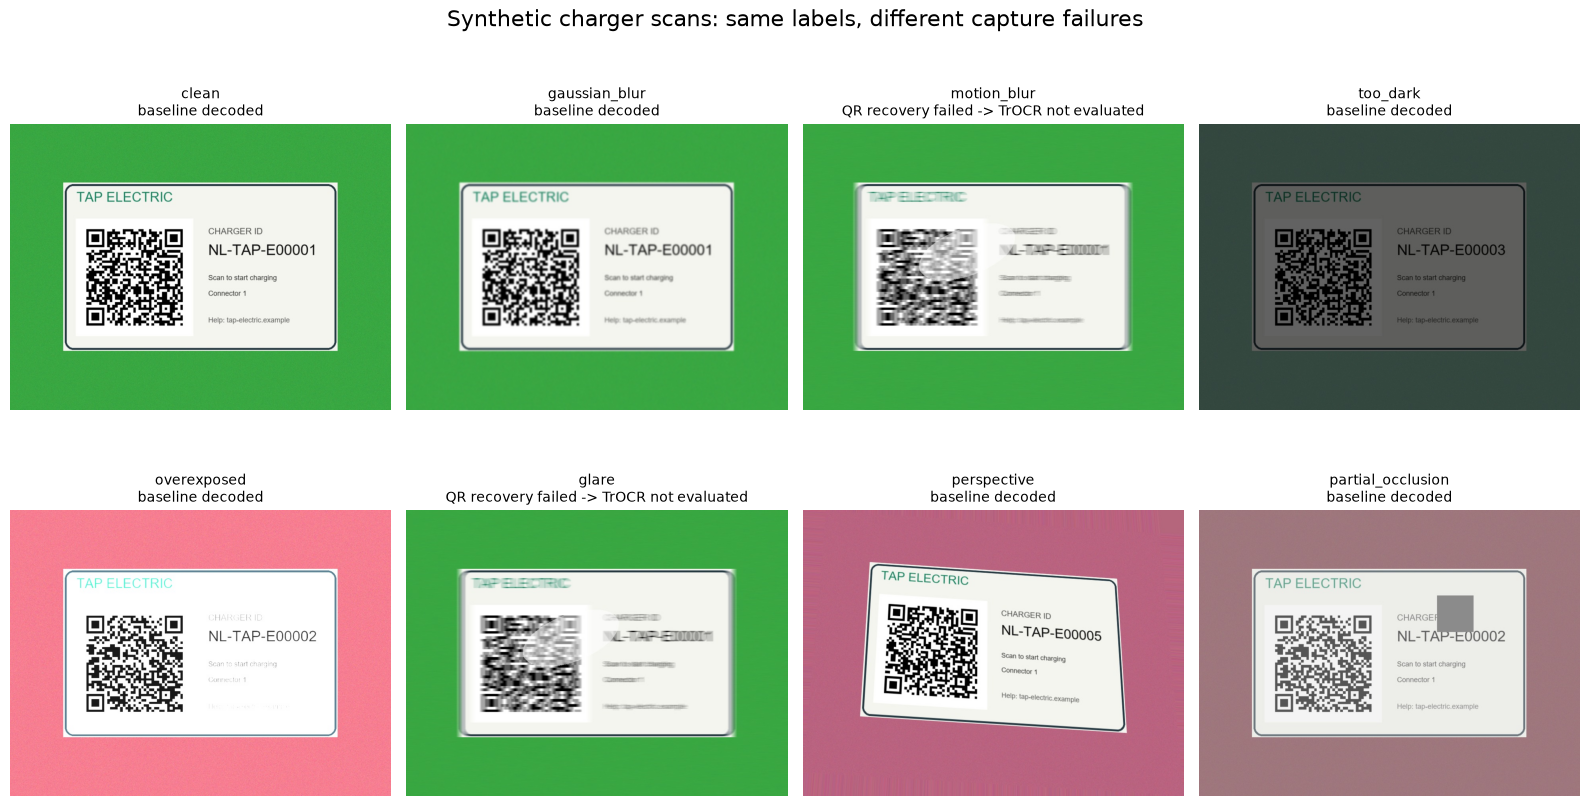

In [3]:
expanded = samples.explode('degradations')
wanted = [
    'clean',
    'gaussian_blur',
    'motion_blur',
    'too_dark',
    'overexposed',
    'glare',
    'perspective',
    'partial_occlusion',
]
chosen = []
for degradation in wanted:
    matches = expanded[expanded['degradations'] == degradation]
    if not matches.empty:
        chosen.append(matches.iloc[0])

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for axis, row in zip(axes.flat, chosen, strict=False):
    axis.imshow(Image.open(OUTPUT_DIR / row['image_path']))
    if row['native_qr_success']:
        state = 'baseline decoded'
    elif row['recovered_qr_success']:
        state = f"recovered: {row['recovery_strategy']} / {row['recovery_decoder']}"
    else:
        state = 'QR recovery failed -> TrOCR not evaluated'
    axis.set_title(f"{row['degradations']}\n{state}", fontsize=10)
    axis.axis('off')
for axis in axes.flat[len(chosen):]:
    axis.axis('off')
fig.suptitle('Synthetic charger scans: same labels, different capture failures', fontsize=16)
plt.tight_layout()

## 3. Baseline versus multi-pass QR recovery

OpenCV provides the fast baseline. Failed images then pass through quality-directed contrast, sharpening, thresholding and upscaling before OpenCV and ZXing-C++ retry them. Remaining failures continue to printed-ID OCR, GPS-assisted resolution or manual entry.

,examples,baseline,after_recovery
degradations,,,
motion_blur,42,0.0%,16.7%
noise,20,60.0%,75.0%
partial_occlusion,10,60.0%,70.0%
gaussian_blur,42,61.9%,97.6%
faded,14,64.3%,85.7%
perspective,16,75.0%,81.2%
glare,15,80.0%,93.3%
too_dark,13,84.6%,100.0%
jpeg_compression,11,90.9%,90.9%


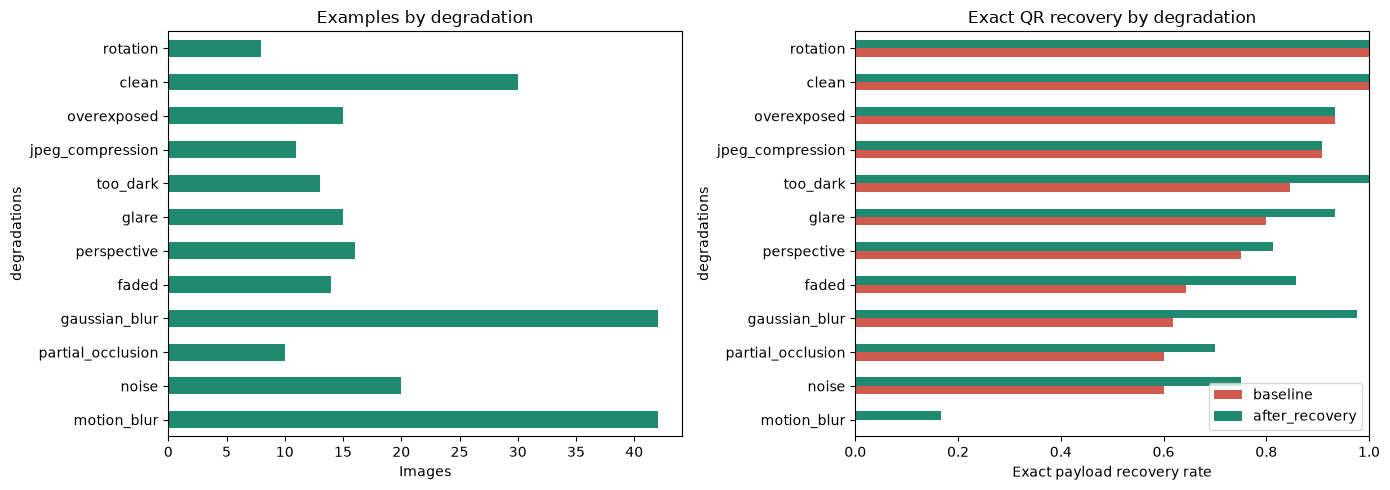

In [4]:
degradation_report = (
    expanded.groupby('degradations')
    .agg(
        examples=('example_id', 'count'),
        baseline=('native_qr_success', 'mean'),
        after_recovery=('recovered_qr_success', 'mean'),
    )
    .sort_values('baseline')
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
degradation_report['examples'].plot.barh(
    ax=axes[0], color='#1f8a70', title='Examples by degradation'
)
degradation_report[['baseline', 'after_recovery']].plot.barh(
    ax=axes[1],
    color=['#d05a4e', '#1f8a70'],
    title='Exact QR recovery by degradation',
)
axes[0].set_xlabel('Images')
axes[1].set_xlabel('Exact payload recovery rate')
axes[1].set_xlim(0, 1)
plt.tight_layout()
degradation_report.style.format({'baseline': '{:.1%}', 'after_recovery': '{:.1%}'})

## 4. Quality signals explain recovery and fallback decisions

Blur uses variance of the Laplacian; brightness is mean grayscale intensity. These are operational signals used by the service to choose preprocessing, not labels supplied to TrOCR.

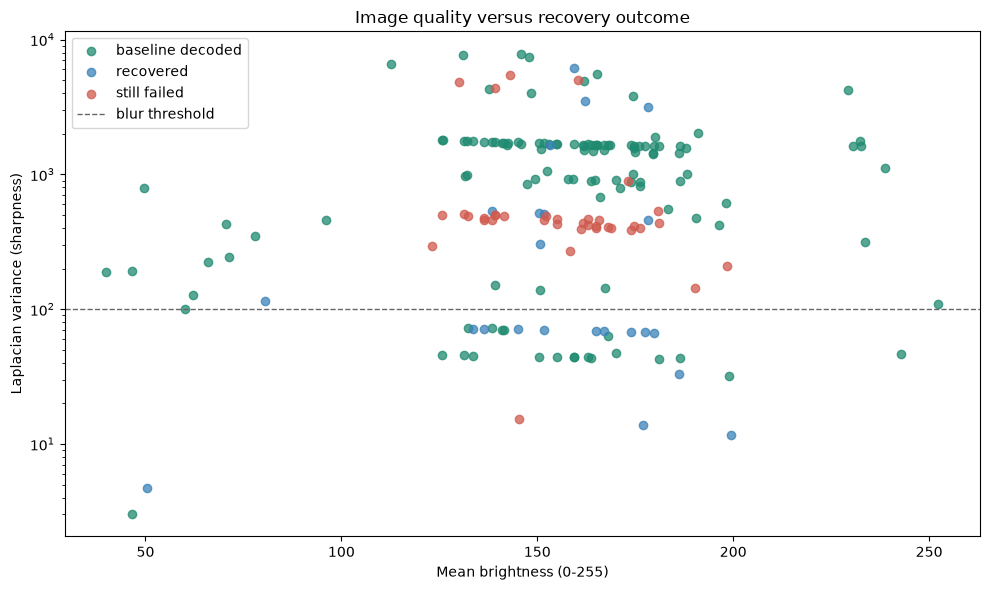

In [5]:
recovery_status = pd.Series('still failed', index=samples.index)
recovery_status.loc[samples['recovered_qr_success']] = 'recovered'
recovery_status.loc[samples['native_qr_success']] = 'baseline decoded'
plot_samples = samples.assign(recovery_status=recovery_status)
status_colors = {
    'baseline decoded': '#1f8a70',
    'recovered': '#3b82b8',
    'still failed': '#d05a4e',
}
fig, axis = plt.subplots(figsize=(10, 6))
for status, group in plot_samples.groupby('recovery_status'):
    axis.scatter(
        group['brightness_score'],
        group['blur_score'],
        c=status_colors[status],
        label=status,
        alpha=0.75,
    )
axis.axhline(100, color='#666666', linestyle='--', linewidth=1, label='blur threshold')
axis.set_xlabel('Mean brightness (0-255)')
axis.set_ylabel('Laplacian variance (sharpness)')
axis.set_yscale('log')
axis.set_title('Image quality versus recovery outcome')
axis.legend()
plt.tight_layout()

## 5. Verify that the split has no sticker leakage

In [6]:
splits_per_sticker = samples.groupby('sticker_id')['split'].nunique()
assert splits_per_sticker.max() == 1
assert samples.groupby('image_sha256')['split'].nunique().max() == 1
print(
    f"Leakage check passed: all {len(splits_per_sticker)} stickers and "
    "duplicate hashes stay in one split."
)

Leakage check passed: all 30 stickers and duplicate hashes stay in one split.


## 6. Hybrid data sources

| Layer | Purpose | Source and policy |
|---|---|---|
| Synthetic stickers | Exact printed-ID labels for TrOCR; controlled failure coverage | Generated by this repository; safe to version by seed |
| Damaged QR pairs | Restoration and decoder benchmarking | [Kaggle: Damaged QR and Barcode Data](https://www.kaggle.com/datasets/tmuallim/damaged-qr-and-barcode-data), CC BY 4.0 |
| Unreadable QR benchmark | Scanned and simulated failure cases | [Figshare: QR Code Dataset V2](https://figshare.com/articles/dataset/QR_Code_Dataset_V2/28424213), CC BY 4.0 |
| Physical captures | Reality check for camera, glare, surface and device shift | Print synthetic stickers; hold photos out from training |
| Confirmed Tap scans | Final domain adaptation and production validation | Collected through the API with retention and access controls |

Third-party files are not committed automatically. Their provenance and licence must be recorded, and labels remain pending review unless the manifest explicitly marks them verified.

## 7. Fine-tune and evaluate TrOCR

This optional section fine-tunes `microsoft/trocr-base-printed` to read the printed charger ID. It uses the existing charger-group split, so validation and test chargers are never used for training.

Run it on a Kaggle GPU by enabling the GPU accelerator and changing `RUN_TROCR` to `True`. The normalized crop below matches the generated sticker layout; production images require a detected sticker or identifier region.

The output is a synthetic proof of concept, not a production-accuracy claim.

In [7]:
RUN_TROCR = False  # Set to True in a Kaggle notebook with GPU enabled
TROCR_MODEL_NAME = 'microsoft/trocr-base-printed'
TROCR_EPOCHS = 3
TROCR_BATCH_SIZE = 2

if RUN_TROCR:
    subprocess.run(
        [
            sys.executable,
            '-m',
            'pip',
            'install',
            '-q',
            'transformers>=4.45,<5.0',
            'accelerate>=0.34,<2.0',
        ],
        check=True,
    )
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError('Enable a GPU accelerator before running TrOCR fine-tuning.')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('TrOCR cells are disabled. Set RUN_TROCR=True on Kaggle to run them.')

TrOCR cells are disabled. Set RUN_TROCR=True on Kaggle to run them.


In [8]:
if RUN_TROCR:
    from torch.utils.data import Dataset
    from transformers import (
        Seq2SeqTrainer,
        Seq2SeqTrainingArguments,
        TrOCRProcessor,
        VisionEncoderDecoderModel,
    )

    from app.ml.evaluate import evaluate_predictions
    from app.ml.metrics import character_error_rate, exact_match_accuracy

    def identifier_crop(image):
        width, height = image.size
        return image.crop(
            (int(width * 0.48), int(height * 0.34), int(width * 0.94), int(height * 0.53))
        )

    processor = TrOCRProcessor.from_pretrained(TROCR_MODEL_NAME)

    class SyntheticIdentifierDataset(Dataset):
        def __init__(self, frame):
            self.frame = frame.reset_index(drop=True)

        def __len__(self):
            return len(self.frame)

        def __getitem__(self, index):
            row = self.frame.iloc[index]
            image = Image.open(OUTPUT_DIR / row['image_path']).convert('RGB')
            pixels = processor(
                images=identifier_crop(image), return_tensors='pt'
            ).pixel_values[0]
            labels = processor.tokenizer(
                row['charger_id'],
                padding='max_length',
                max_length=32,
                truncation=True,
                return_tensors='pt',
            ).input_ids[0]
            labels[labels == processor.tokenizer.pad_token_id] = -100
            return {'pixel_values': pixels, 'labels': labels}

    train_frame = samples[samples['split'] == 'train'].copy()
    validation_frame = samples[samples['split'] == 'validation'].copy()
    test_frame = samples[samples['split'] == 'test'].copy()
    train_dataset = SyntheticIdentifierDataset(train_frame)
    validation_dataset = SyntheticIdentifierDataset(validation_frame)
    test_dataset = SyntheticIdentifierDataset(test_frame)

    model = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL_NAME)
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.vocab_size = model.config.decoder.vocab_size

    def compute_trocr_metrics(prediction):
        prediction_ids = prediction.predictions
        if isinstance(prediction_ids, tuple):
            prediction_ids = prediction_ids[0]
        label_ids = prediction.label_ids.copy()
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        predicted_text = processor.batch_decode(prediction_ids, skip_special_tokens=True)
        reference_text = processor.batch_decode(label_ids, skip_special_tokens=True)
        return {
            'exact_match': exact_match_accuracy(predicted_text, reference_text),
            'character_error_rate': character_error_rate(predicted_text, reference_text),
        }

    training_output = Path('/kaggle/working/trocr-charger-id')
    training_arguments = Seq2SeqTrainingArguments(
        output_dir=str(training_output),
        num_train_epochs=TROCR_EPOCHS,
        per_device_train_batch_size=TROCR_BATCH_SIZE,
        per_device_eval_batch_size=TROCR_BATCH_SIZE,
        gradient_accumulation_steps=2,
        learning_rate=5e-5,
        fp16=True,
        predict_with_generate=True,
        generation_max_length=32,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='exact_match',
        greater_is_better=True,
        logging_steps=10,
        report_to=[],
    )
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_arguments,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        processing_class=processor,
        compute_metrics=compute_trocr_metrics,
    )
    print(
        f'TrOCR examples: {len(train_dataset)} train, '
        f'{len(validation_dataset)} validation, {len(test_dataset)} test'
    )

In [9]:
if RUN_TROCR:
    trainer.train()
    final_model_path = training_output / 'final'
    trainer.save_model(final_model_path)
    processor.save_pretrained(final_model_path)
    print(f'Saved fine-tuned model to {final_model_path}')

In [10]:
if RUN_TROCR:
    test_output = trainer.predict(test_dataset)
    prediction_ids = test_output.predictions
    if isinstance(prediction_ids, tuple):
        prediction_ids = prediction_ids[0]
    label_ids = test_output.label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    trocr_predictions = [
        text.strip()
        for text in processor.batch_decode(prediction_ids, skip_special_tokens=True)
    ]
    references = [
        text.strip()
        for text in processor.batch_decode(label_ids, skip_special_tokens=True)
    ]

    results = test_frame.reset_index(drop=True).copy()
    results['trocr_prediction'] = trocr_predictions
    results['trocr_exact'] = results['trocr_prediction'] == results['charger_id']
    results['qr_stage_failed'] = ~results['recovered_qr_success']
    results['pipeline_success'] = results['recovered_qr_success'] | results['trocr_exact']
    degradation_types = [
        'clean_or_unknown' if values == ['clean'] else values[0]
        for values in results['degradations']
    ]
    report = evaluate_predictions(
        trocr_predictions,
        references,
        degradation_types,
        results['qr_stage_failed'].tolist(),
    )
    fallback_count = int(results['qr_stage_failed'].sum())
    additional_recoveries = int(
        (results['qr_stage_failed'] & results['trocr_exact']).sum()
    )
    metric_table = pd.Series(
        {
            'TrOCR exact-match accuracy': report.metrics.exact_match_accuracy,
            'TrOCR character error rate': report.metrics.character_error_rate,
            'TrOCR recovery rate on QR failures': report.metrics.qr_recovery_rate,
            'Clean-scan TrOCR accuracy': report.metrics.clean_scan_accuracy,
            'Degraded-scan TrOCR accuracy': report.metrics.degraded_scan_accuracy,
            'End-to-end pipeline success rate': float(results['pipeline_success'].mean()),
            'QR failures evaluated by TrOCR': fallback_count,
            'Additional scans recovered by TrOCR': additional_recoveries,
        },
        name='value',
    ).to_frame()
    display(metric_table)
    display(
        pd.Series(report.accuracy_by_degradation, name='exact_match')
        .rename_axis('degradation')
        .to_frame()
    )
    display(
        results.loc[
            results['qr_stage_failed'],
            ['charger_id', 'trocr_prediction', 'trocr_exact', 'degradations'],
        ].head(12)
    )

## Key findings

The executed decoder section measures baseline and preprocessing recovery. After the optional GPU cells run, the notebook also reports held-out TrOCR exact match, character error rate, recovery of QR-decoder failures, clean/degraded accuracy, and end-to-end pipeline success. Synthetic results verify mechanics; physical and confirmed domain scans remain necessary for production validation.